# SAE estimations for MPI in Cambodia

In [1]:
#Imports  
import pandas as pd
import geopandas as gpd
import os 
import numpy as np
import matplotlib.pyplot as plt

c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
#Parameters
nis_year = 2011
dhs_year = 2010

#Load NIS information
#These files contain the variable equivalence between the NIS and DHS datasets. 
common_variables_path = f'data/common_variables.xlsx'
common_variables = pd.read_excel(common_variables_path)

### Load NIS data

In [3]:
nis_raw_data_path = f'data/NIS{nis_year}_Village_Year_Coords.xlsx'
nis_mpi_data_path = f'data/MPI_NIS_{nis_year}.xlsx'

nis_columns = common_variables['NIS_code'].to_list() #Only load the MPI related columns 
nis_columns = [x for x in nis_columns if not pd.isna(x)] #Drop nan to load the file properly
nis = pd.read_excel(nis_mpi_data_path)#, usecols=nis_columns)

In [4]:
#Read villages shape file
villages_path = r'data/Villages.shp'
villages = gpd.read_file(villages_path)

c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files. Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()


In [5]:
nis = villages[['PHUMCODE','geometry']].merge(nis, left_on='PHUMCODE', right_on='VillGis', how='right')

In [6]:
nis = nis[['PHUMCODE', 	'geometry'] + nis_columns]

### Load DHS data

In [20]:
#Load DHS  (rate indicators (Methodology 4): households deprived out of the total number of households per psu) 
dhs_path = f'data/mpi_met4_dhs10.csv'
dhs = pd.read_csv(dhs_path)

In [21]:
dhs.head()

,psu,area,region,region_01,rate_cm,rate_nutr,rate_satt,rate_educ,rate_elct,rate_wtr,...,depr_nutr,depr_educ,depr_satt,depr_wtr,depr_sani,depr_hsg,depr_elct,depr_asst,depr_ckfl,mpi_met4
0,1,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.071429,0.000000,0.214286,0.071429,0.142857,...,0,1,0,0,0,0,0,0,1,0.222222
1,2,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.090909,0.000000,0.230769,0.615385,0.307692,...,0,1,0,1,0,0,1,0,1,0.333333
2,3,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.090909,0.076923,0.461538,0.307692,0.153846,...,0,1,0,0,1,0,1,0,1,0.333333
3,4,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.363636,0.090909,0.272727,1.000000,0.272727,...,1,1,0,0,1,1,1,0,1,0.555556
4,5,urban,Banteay Meanchay,Banteay Meanchay,0.0,0.454545,0.090909,0.000000,0.000000,0.090909,...,1,0,0,0,0,0,0,0,1,0.222222


In [22]:
selected_dhs_variables = ['psu', 'area', 'region', 'region_01', 'rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct', 'rate_wtr', 'rate_sani', 'rate_hsg', 'rate_ckfl', 'rate_asst']


In [23]:
#Attach cluster geometries to DHS cluster-level data (DHS)
dhs_shape_path = f'data/mpi_khm_dhs10_hmn_clust_CI_mis.shp'
dhs_shape = gpd.read_file(dhs_shape_path)

In [24]:
dhs_shape.head()

,DHSID,DHSCC,DHSYEAR,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,...,mpi_0_SE,mpi_0_loCI,mpi_0_upCI,mpi_3,mpi_3_SE,mpi_3_loCI,mpi_3_upCI,tot_ppl,pct_pplmis,geometry
0,KH201000000001,KH,2010.0,1.0,CB,NULL,NULL,NULL,NULL,9999.0,...,0.020746,0.057435,0.147074,0.004831,0.005157,-0.006310,0.015972,69,0.000000,POINT (103.01734 13.51884)
1,KH201000000002,KH,2010.0,2.0,CB,NULL,NULL,NULL,NULL,9999.0,...,0.032923,0.124710,0.271426,0.039855,0.035169,-0.038507,0.118217,56,17.857140,POINT (102.94996 13.44993)
2,KH201000000003,KH,2010.0,3.0,CB,NULL,NULL,NULL,NULL,9999.0,...,0.064347,0.084887,0.371635,0.175121,0.075628,0.006612,0.343630,57,19.298244,POINT (103.03584 13.45114)
3,KH201000000004,KH,2010.0,4.0,CB,NULL,NULL,NULL,NULL,9999.0,...,0.052763,0.214889,0.450014,0.238977,0.079662,0.061479,0.416475,63,0.000000,POINT (102.98107 13.4443)
4,KH201000000005,KH,2010.0,5.0,CB,NULL,NULL,NULL,NULL,9999.0,...,0.039674,0.077275,0.254074,0.048611,0.046938,-0.055972,0.153195,56,0.000000,POINT (103.01913 13.51521)


In [25]:
dhs_shape.columns.tolist()

['DHSID',
 'DHSCC',
 'DHSYEAR',
 'DHSCLUST',
 'CCFIPS',
 'ADM1FIPS',
 'ADM1FIPSNA',
 'ADM1SALBNA',
 'ADM1SALBCO',
 'ADM1DHS',
 'ADM1NAME',
 'DHSREGCO',
 'DHSREGNA',
 'SOURCE',
 'URBAN_RURA',
 'LATNUM',
 'LONGNUM',
 'ALT_GPS',
 'ALT_DEM',
 'DATUM',
 'clust_no',
 'area',
 'region',
 'mpi_0',
 'mpi_0_SE',
 'mpi_0_loCI',
 'mpi_0_upCI',
 'mpi_3',
 'mpi_3_SE',
 'mpi_3_loCI',
 'mpi_3_upCI',
 'tot_ppl',
 'pct_pplmis',
 'geometry']

In [26]:

#Drop almos zero coordinates
# Define a small threshold for "almost zero"
epsilon = 1e-10

# Filter out points near (0, 0)
dhs_shape = dhs_shape[~(
    (np.abs(dhs_shape.geometry.x) < epsilon) &
    (np.abs(dhs_shape.geometry.y) < epsilon)
)]

In [27]:
#Keep only the rural clusters
dhs_shape = dhs_shape[dhs_shape['URBAN_RURA'] == 'R'] #Only rural clusters

In [28]:
dhs = dhs_shape[['DHSCLUST', 'geometry']].merge(dhs, right_on='psu', left_on='DHSCLUST', how='left')

In [29]:
dhs.head()

,DHSCLUST,geometry,psu,area,region,region_01,rate_cm,rate_nutr,rate_satt,rate_educ,...,depr_nutr,depr_educ,depr_satt,depr_wtr,depr_sani,depr_hsg,depr_elct,depr_asst,depr_ckfl,mpi_met4
0,1.0,POINT (103.01734 13.51884),1,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.071429,0.000000,0.214286,...,0,1,0,0,0,0,0,0,1,0.222222
1,2.0,POINT (102.94996 13.44993),2,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.090909,0.000000,0.230769,...,0,1,0,1,0,0,1,0,1,0.333333
2,3.0,POINT (103.03584 13.45114),3,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.090909,0.076923,0.461538,...,0,1,0,0,1,0,1,0,1,0.333333
3,4.0,POINT (102.98107 13.4443),4,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.363636,0.090909,0.272727,...,1,1,0,0,1,1,1,0,1,0.555556
4,7.0,POINT (103.09797 13.45698),7,rural,Banteay Meanchay,Banteay Meanchay,0.0,0.285714,0.142857,0.500000,...,1,1,0,1,1,1,1,0,1,0.611111


In [30]:
#Import the dictionary with the common variables
common_variables

,Description,DHS_code,Rate variable (methodology 4),Description.1,NIS_code,DUMMY
0,Household had child mortality under 18 in the ...,d_cm,rate_cm,Child mortality rate calculated as the proport...,523-C_MORT_RATE,536-C_MORT_DUM
1,Household has individuals malnourished,d_nutr,rate_nutr,NaN,NaN,NaN
2,Household has not all school age children up t...,d_satt,rate_satt,NaN,NaN,NaN
3,Household has less one member with 6 years of ...,d_educ,rate_educ,Illiterate population rate calculated as the p...,513-ILLITERATE_RATE,537-ILLIT_DUM
4,Household doesn't electricity,d_elct,rate_elct,Household with electricity rate calculated as ...,534-LQ_ROOF_ELEC_RATE,540-HOUSE_ELEC_DUM
5,"Household has roof, floor and walls with low q...",d_hsg,rate_hsg,Low quality material roofs rate calculated as ...,NaN,NaN
6,Household does not have drinking water with MD...,d_wtr,rate_wtr,"Rate of families with unimproved (pond, rivers...",517-UNIMPROV_WAT_RATE,538-UNIMPROV_WAT_DUM
7,Household does not improved sanitation with M...,d_sani,rate_sani,Household with latrines rate calculated as the...,532-Sanit_Rate,539-SANIT_DUM
8,Household does not accomplish cooking fuel by ...,d_ckfl,rate_ckfl,NaN,NaN,NaN
9,Household Asset Ownership: HH doesn't have car...,d_asst,rate_asst,Rate of assets owneship (mobility & agricultur...,531-AGRI_ASSETS_RATE,NaN


In [31]:
nis = nis[nis.geometry.notnull()] #Exclude null geometries
print(nis["geometry"].duplicated().sum()) #Check if there are null geometries
print(nis["PHUMCODE"].duplicated().sum()) #Check if there are duplicated PHUMCODE

3
0


In [32]:
dhs = dhs.to_crs(nis.crs)

In [33]:
dhs.to_file(fr'data/underlying/sae-dhs-underlying-{dhs_year}.shp')


In [34]:
nis.to_file(fr'data/underlying/sae-nis-complete-{nis_year}.shp')

C:\Users\nicol\AppData\Local\Temp\ipykernel_31828\2927337131.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nis.to_file(fr'data/underlying/sae-nis-complete-{nis_year}.shp')
c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '523-C_MORT_RATE' to '523-C_MORT'
  ogr_write(
c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '513-ILLITERATE_RATE' to '513-ILLITE'
  ogr_write(
c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '534-LQ_ROOF_ELEC_RATE' to '534-LQ_ROO'
  ogr_write(
c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: '517-UNIMPROV_WAT_RATE' to '517-UNIMPR'
  ogr_write(
c:\Users\nicol\anaconda3\envs\dises\Lib\site-packages\pyogrio\raw.py:7

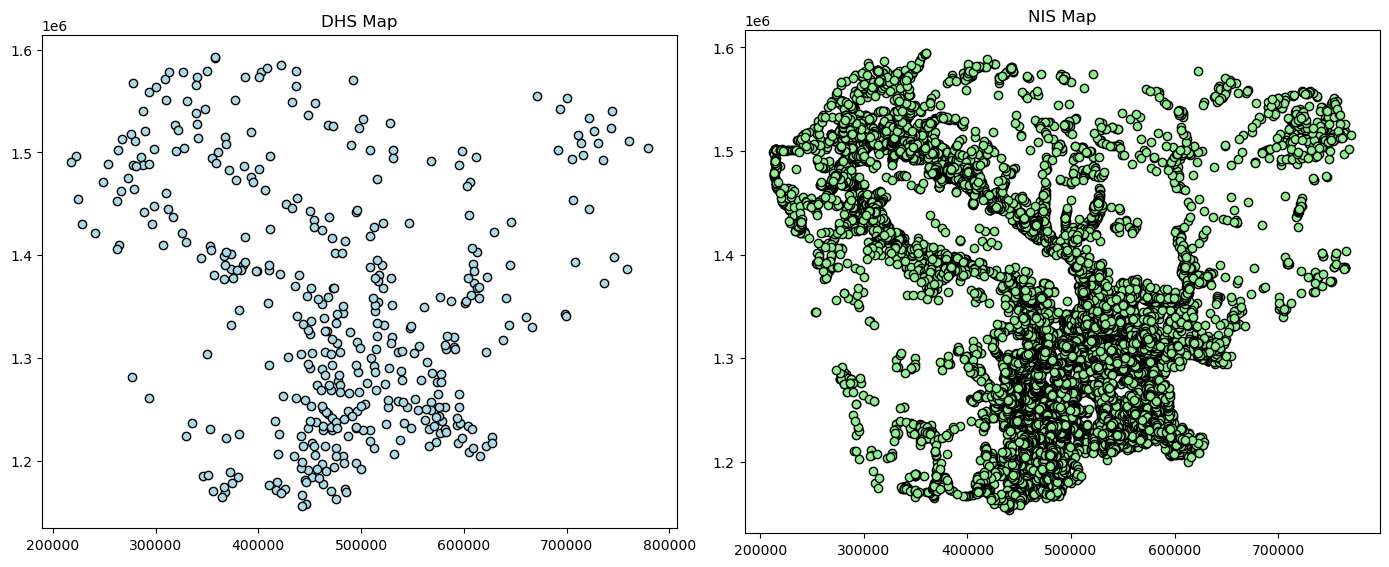

In [35]:

# Plotting the NIS and DHS maps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # high x wide in inches

dhs.plot(ax=axes[0], color='lightblue', edgecolor='black')
axes[0].set_title('DHS Map')

nis.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('NIS Map')

plt.tight_layout()
plt.show()
